# Baseline Model Analysis for Carbon Flux Thesis

**Purpose:** Comprehensive analysis of baseline models (Random Forest, XGBoost, LSTM)

**Author:** Paul Ezennolim  
**Thesis:** Temporal-spatial data fusion for carbon flux quatification in agroecosystems: a multimodal learning approach

---

This notebook analyzes the performance of three baseline models:
- **Random Forest** (tree-based ensemble)
- **XGBoost** (gradient boosting)
- **LSTM** (deep learning sequential model)

Evaluated on two held-out test sites:
- **UK-AMo** (Auchencorth Moss - Peatland)
- **SE-Htm** (Hyltemossa - Forest)

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Paths
RESULTS_DIR = Path('results') 
METRICS_DIR = RESULTS_DIR / 'metrics'
PREDS_DIR = RESULTS_DIR / 'predictions'
DATA_DIR = Path('data/processed') 
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True, parents=True)

# Sites and models
SITES = ['UK-AMo', 'SE-Htm']
MODEL_DISPLAY = {
    'randomforest': 'Random Forest',
    'xgboost': 'XGBoost',
    'lstm': 'LSTM',
}
COLORS = {'Random Forest': '#3498db', 'XGBoost': '#2ecc71', 'LSTM': '#e74c3c'}

# Verify paths work
print('✓ Setup complete')

✓ Setup complete


## 1. Load Baseline Model Results

Loading performance metrics from all three baseline models.

In [ ]:
# Load baseline metrics from CSV (train_baselines.py saves here)
csv_path = METRICS_DIR / 'baseline_results.csv'

if csv_path.exists():
    print(f"✓ Loading baseline metrics from: {csv_path.name}\n")
    
    # Read CSV
    csv_df = pd.read_csv(csv_path)
    
    # Convert to dictionary format expected by rest of code
    metrics_data = {}
    
    # Map CSV model names to keys used in MODEL_DISPLAY
    csv_to_key = {
        'RandomForest': 'randomforest',
        'XGBoost': 'xgboost',
        'LSTM': 'lstm'
    }
    
    for csv_model_name, model_key in csv_to_key.items():
        if model_key not in MODEL_DISPLAY:
            continue
            
        metrics_data[model_key] = {}
        
        for site in SITES:
            row = csv_df[(csv_df['Model'] == csv_model_name) & (csv_df['Site'] == site)]
            if not row.empty:
                metrics_data[model_key][site] = {
                    'RMSE': float(row['RMSE'].values[0]),
                    'MAE': float(row['MAE'].values[0]),
                    'R2': float(row['R2'].values[0])
                }
    
    print(f"✓ Loaded {len(metrics_data)} baseline models")
else:
    print(f"❌ {csv_path} not found!")
    print("   Run: python scripts/train_baselines.py")
    metrics_data = {}

# Build comparison DataFrame
comparison_rows = []
for model_key, model_metrics in metrics_data.items():
    display_name = MODEL_DISPLAY[model_key]
    for site in SITES:
        if site not in model_metrics:
            continue
        m = model_metrics[site]
        vals = [m.get('RMSE'), m.get('MAE'), m.get('R2')]
        if any(v is None or (isinstance(v, float) and np.isnan(v)) for v in vals):
            continue
        comparison_rows.append({
            'Model': display_name,
            'Site': site,
            'RMSE': m['RMSE'],
            'MAE': m['MAE'],
            'R²': m['R2'],
        })

if comparison_rows:
    comparison_df = pd.DataFrame(comparison_rows)
    valid_models = sorted(comparison_df['Model'].unique())
    
    display(
        comparison_df.pivot_table(index='Model', columns='Site',
                                  values=['RMSE', 'MAE', 'R²'])
        .round(4)
        .style
        .background_gradient(cmap='RdYlGn_r', subset=pd.IndexSlice[:, ['RMSE', 'MAE']])
        .background_gradient(cmap='RdYlGn', subset=pd.IndexSlice[:, ['R²']])
        .format('{:.4f}')
        .set_caption('Table: Baseline Model Performance Comparison')
    )
else:
    print("❌ No valid baseline metrics found")

✓ Loading baseline metrics from: baseline_results.csv

✓ Loaded 3 baseline models


## 2. Cross-Site Performance Comparison

Visualizing baseline model performance across test sites.

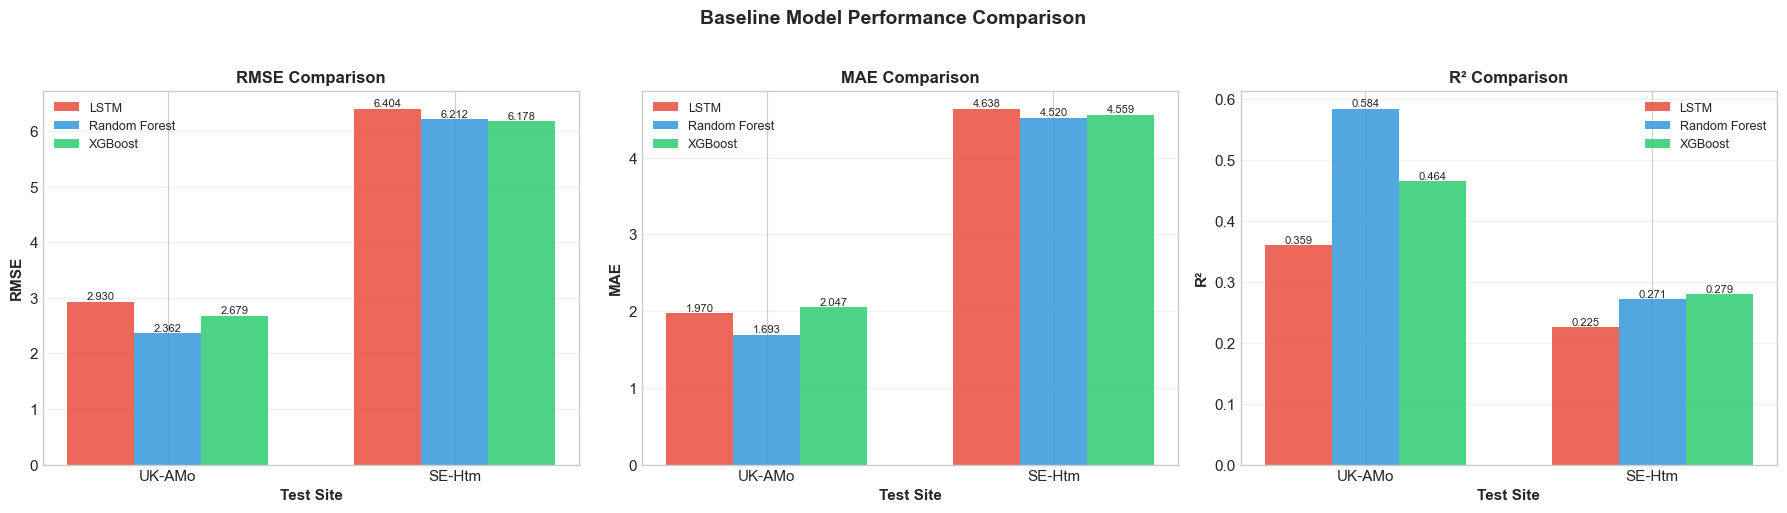

Figure saved: baseline_comparison.png


In [12]:
metrics_list = ['RMSE', 'MAE', 'R\u00b2']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, metric in enumerate(metrics_list):
    ax = axes[idx]
    x = np.arange(len(SITES))
    n_models = len(valid_models)
    width = 0.7 / max(n_models, 1)

    for i, model in enumerate(valid_models):
        vals = []
        for site in SITES:
            row = comparison_df[
                (comparison_df['Model'] == model) &
                (comparison_df['Site'] == site)
            ]
            vals.append(row[metric].values[0] if len(row) else 0)

        offset = (i - (n_models - 1) / 2) * width
        bars = ax.bar(
            x + offset, vals, width,
            label=model, color=COLORS.get(model, f'C{i}'), alpha=0.85,
        )
        for bar in bars:
            h = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2, h,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8,
            )

    ax.set_xlabel('Test Site', fontsize=11, fontweight='bold')
    ax.set_ylabel(metric, fontsize=11, fontweight='bold')
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(SITES)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle(
    'Baseline Model Performance Comparison',
    fontsize=14, fontweight='bold', y=1.02,
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'baseline_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig(FIG_DIR / 'baseline_comparison.pdf', bbox_inches='tight')
plt.show()
print('Figure saved: baseline_comparison.png')

## 3. Best Performing Model per Site

Identifying which baseline performs best for each ecosystem type.

In [13]:
print('=== Best Models per Site ===\n')
for site in SITES:
    site_df = comparison_df[comparison_df['Site'] == site]
    if site_df.empty:
        print(f'{site}: no valid results')
        continue
    
    best_rmse_row = site_df.loc[site_df['RMSE'].idxmin()]
    best_r2_row = site_df.loc[site_df['R²'].idxmax()]
    
    print(f'{site}:')
    print(f"  Best RMSE: {best_rmse_row['Model']} ({best_rmse_row['RMSE']:.4f})")
    
    r2_value = best_r2_row['R²']
    print(f"  Best R²:   {best_r2_row['Model']} ({r2_value:.4f})")
    print()

=== Best Models per Site ===

UK-AMo:
  Best RMSE: Random Forest (2.3621)
  Best R²:   Random Forest (0.5836)

SE-Htm:
  Best RMSE: XGBoost (6.1782)
  Best R²:   XGBoost (0.2791)



## 4. Load Predictions for Detailed Analysis

Loading actual predictions and targets for error analysis.

In [ ]:
# Load test targets
test_targets = {}
for site in SITES:
    test_targets[site] = np.load(DATA_DIR / f'test_{site}_y.npy')
    print(f'  ✓ Targets {site}: {test_targets[site].shape}')

# Load predictions
predictions = {}
for model_key, display_name in MODEL_DISPLAY.items():
    predictions[display_name] = {}
    for site in SITES:
        for parent in [PREDS_DIR, PREDS_DIR / 'baselines']:
            path = parent / f'{model_key}_preds_{site}.npy'
            if path.exists():
                arr = np.load(path)
                if not np.isnan(arr).any():
                    predictions[display_name][site] = arr
                    print(f'  ✓ {display_name:<16} / {site}: {arr.shape}')
                break

# Models that have valid predictions for plotting
plot_models = [m for m in valid_models if len(predictions[m]) > 0]
print(f'\n  Models available for plotting: {plot_models}')


  ✓ Targets UK-AMo: (9055, 96)
  ✓ Targets SE-Htm: (5007, 96)
  ✓ Random Forest    / UK-AMo: (9055, 96)
  ✓ Random Forest    / SE-Htm: (5007, 96)
  ✓ XGBoost          / UK-AMo: (9055, 96)
  ✓ XGBoost          / SE-Htm: (5007, 96)
  ✓ LSTM             / UK-AMo: (9055, 96)
  ✓ LSTM             / SE-Htm: (5007, 96)

  Models available for plotting: ['LSTM', 'Random Forest', 'XGBoost']


## 5. Sample Forecast Visualization

Visualizing actual vs predicted NEE for sample 96-hour forecast windows.

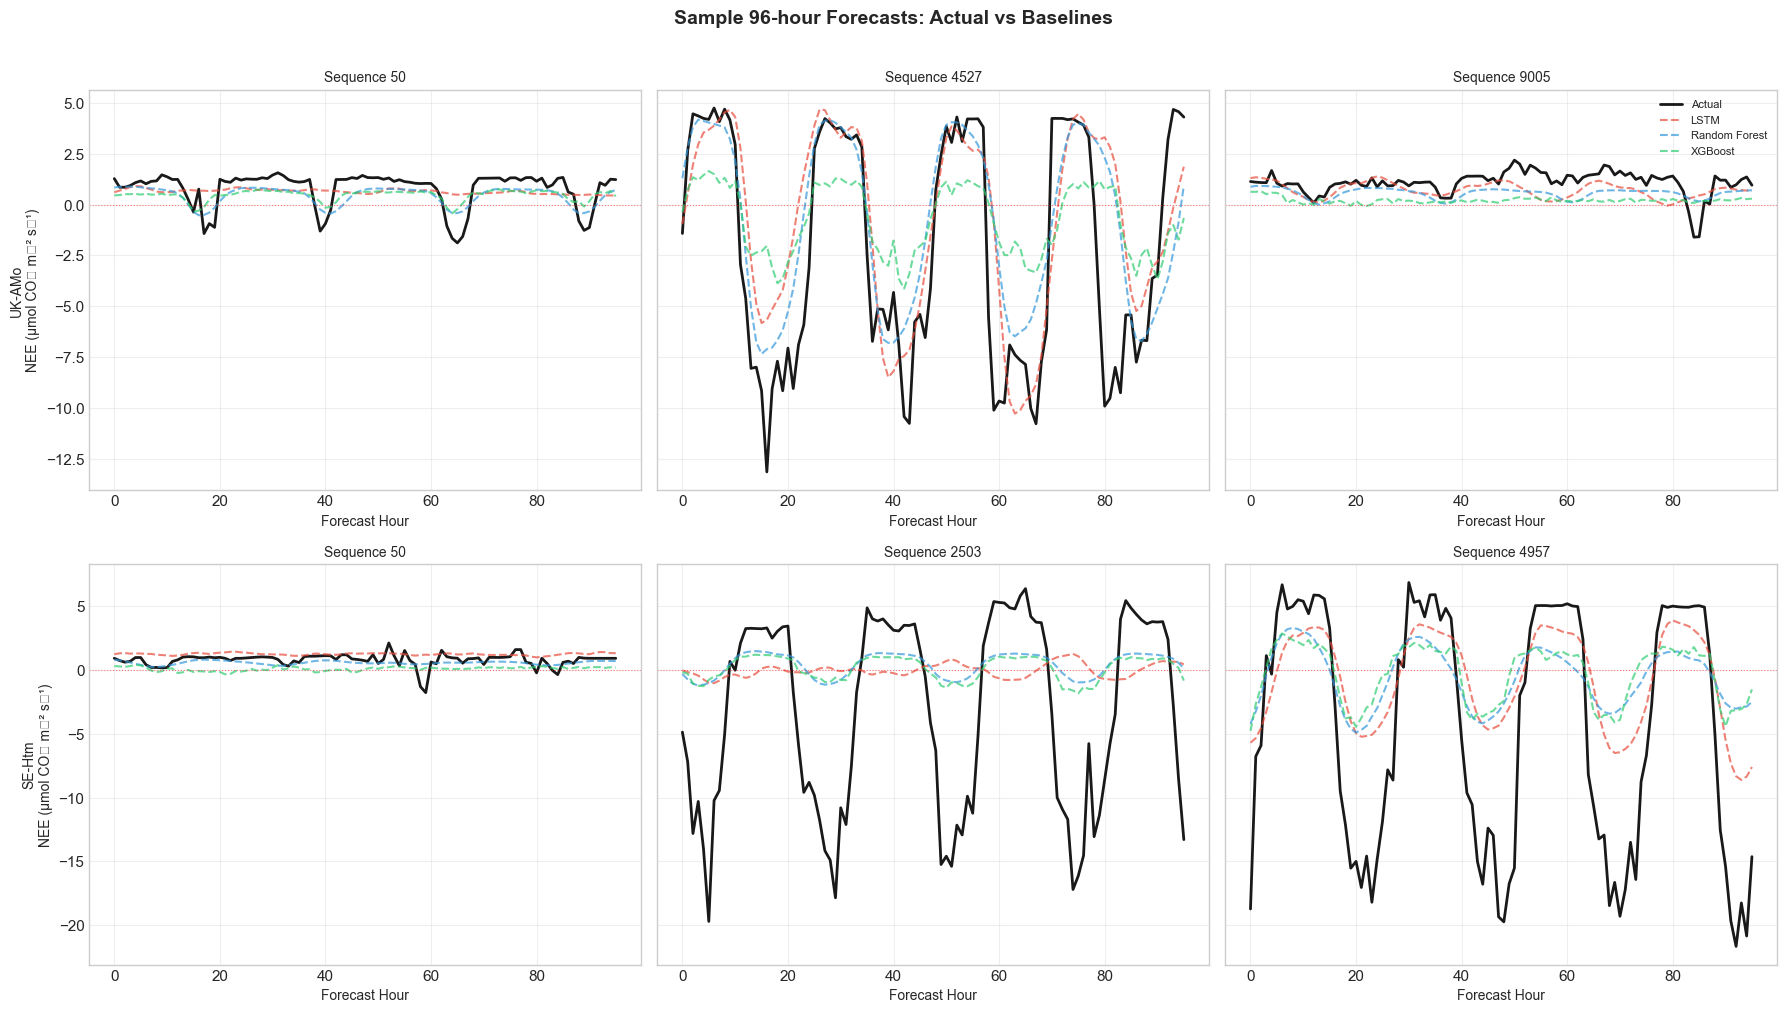

Figure saved: baseline_forecast_examples.png


In [15]:
# Pick three spread-out sample indices per site
n_samples = 3

fig, axes = plt.subplots(
    len(SITES), n_samples, figsize=(6 * n_samples, 5 * len(SITES)),
    sharey='row',
)

for row_idx, site in enumerate(SITES):
    n_seqs = len(test_targets[site])
    sample_indices = np.linspace(50, n_seqs - 50, n_samples, dtype=int)

    for col_idx, seq_idx in enumerate(sample_indices):
        ax = axes[row_idx, col_idx]
        actual = test_targets[site][seq_idx]
        hours = np.arange(len(actual))

        ax.plot(hours, actual, 'k-', linewidth=2, label='Actual', alpha=0.9)

        for model in plot_models:
            if site in predictions[model]:
                pred = predictions[model][site][seq_idx]
                ax.plot(
                    hours, pred, '--', linewidth=1.5,
                    label=model, color=COLORS[model], alpha=0.7,
                )

        ax.axhline(y=0, color='red', linestyle=':', linewidth=0.8, alpha=0.5)
        ax.set_xlabel('Forecast Hour', fontsize=10)
        if col_idx == 0:
            ax.set_ylabel(
                f'{site}\nNEE (\u03bcmol CO\u2082 m\u207b\u00b2 s\u207b\u00b9)',
                fontsize=10,
            )
        ax.set_title(f'Sequence {seq_idx}', fontsize=10)
        ax.grid(True, alpha=0.3)
        if row_idx == 0 and col_idx == n_samples - 1:
            ax.legend(loc='upper right', fontsize=8)

plt.suptitle(
    'Sample 96-hour Forecasts: Actual vs Baselines',
    fontsize=14, fontweight='bold', y=1.01,
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'baseline_forecast_examples.png', dpi=300, bbox_inches='tight')
plt.savefig(FIG_DIR / 'baseline_forecast_examples.pdf', bbox_inches='tight')
plt.show()
print('Figure saved: baseline_forecast_examples.png')

## 6. Error Distribution Analysis

Analyzing prediction error patterns across models and sites.

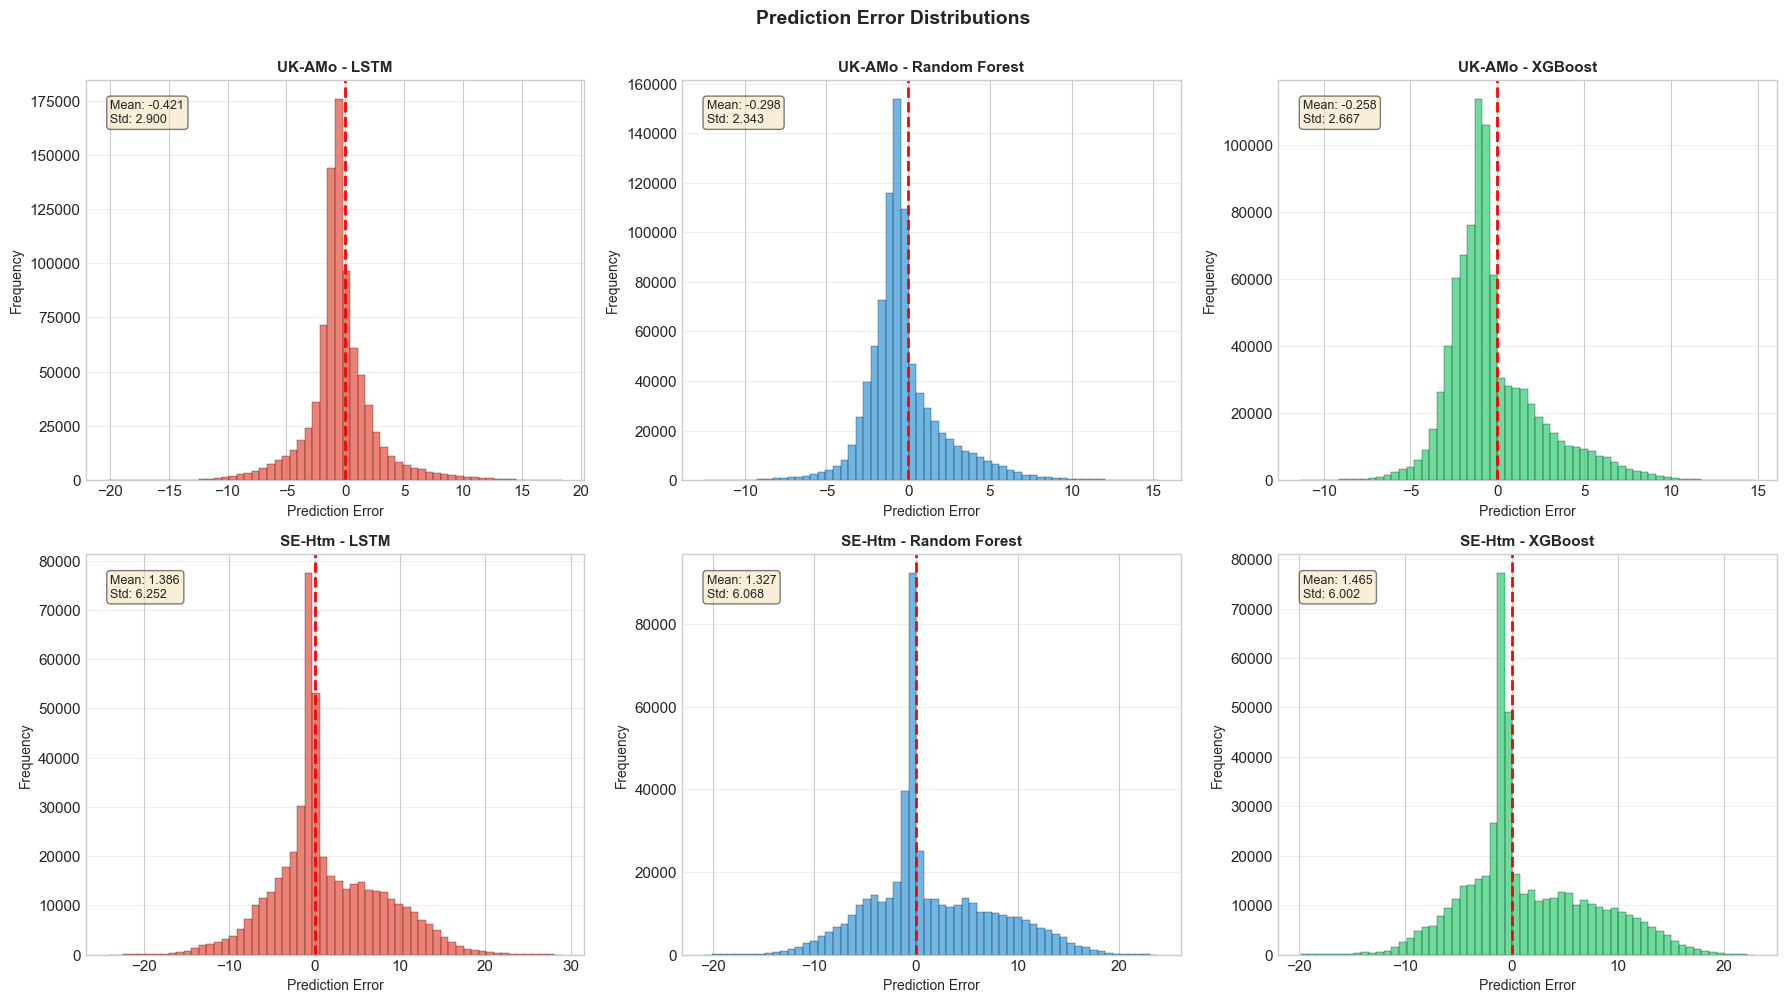

Figure saved: baseline_error_distributions.png


In [16]:
n_plot_models = len(plot_models)
fig, axes = plt.subplots(
    len(SITES), max(n_plot_models, 1),
    figsize=(6 * max(n_plot_models, 1), 5 * len(SITES)),
)
if n_plot_models == 1:
    axes = axes.reshape(-1, 1)

for row_idx, site in enumerate(SITES):
    for col_idx, model in enumerate(plot_models):
        ax = axes[row_idx, col_idx]

        if site not in predictions[model]:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=12)
            ax.set_title(f'{site} - {model}', fontsize=11)
            continue

        actual_flat = test_targets[site].flatten()
        pred_flat = predictions[model][site].flatten()
        errors = pred_flat - actual_flat

        ax.hist(
            errors, bins=60, alpha=0.7,
            color=COLORS[model], edgecolor='black', linewidth=0.3,
        )
        ax.axvline(x=0, color='red', linestyle='--', linewidth=2)

        mean_err = np.mean(errors)
        std_err = np.std(errors)
        ax.text(
            0.05, 0.95,
            f'Mean: {mean_err:.3f}\nStd: {std_err:.3f}',
            transform=ax.transAxes, verticalalignment='top',
            fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
        )

        ax.set_title(f'{site} - {model}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Prediction Error', fontsize=10)
        ax.set_ylabel('Frequency', fontsize=10)
        ax.grid(True, alpha=0.3, axis='y')

plt.suptitle(
    'Prediction Error Distributions',
    fontsize=14, fontweight='bold', y=1.00,
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'baseline_error_distributions.png', dpi=300, bbox_inches='tight')
plt.savefig(FIG_DIR / 'baseline_error_distributions.pdf', bbox_inches='tight')
plt.show()
print('Figure saved: baseline_error_distributions.png')

## 7. Actual vs Predicted Scatter Plots

Assessing prediction quality through scatter plots with R\u00b2 annotations.

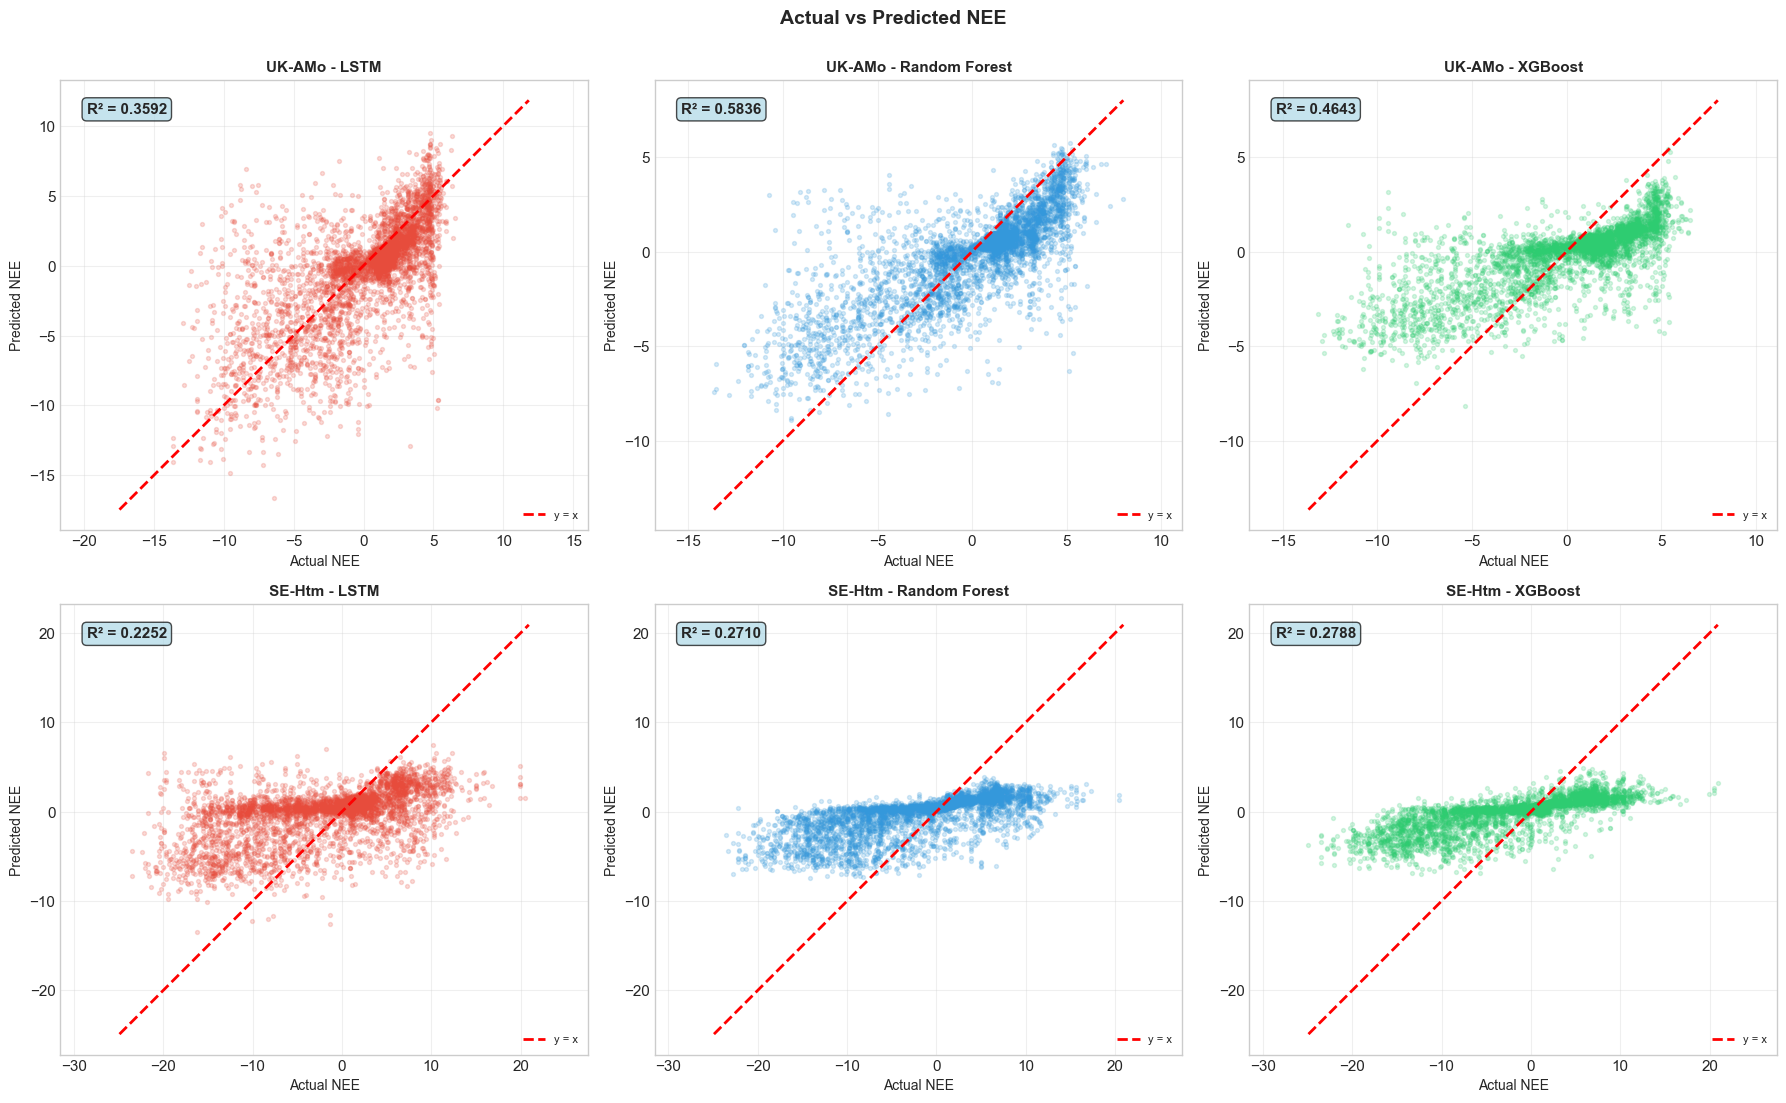

Figure saved: baseline_scatter_plots.png


In [17]:
fig, axes = plt.subplots(
    len(SITES), max(n_plot_models, 1),
    figsize=(6 * max(n_plot_models, 1), 5.5 * len(SITES)),
)
if n_plot_models == 1:
    axes = axes.reshape(-1, 1)

np.random.seed(42)

for row_idx, site in enumerate(SITES):
    for col_idx, model in enumerate(plot_models):
        ax = axes[row_idx, col_idx]

        if site not in predictions[model]:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=12)
            ax.set_title(f'{site} - {model}', fontsize=11)
            continue

        actual_flat = test_targets[site].flatten()
        pred_flat = predictions[model][site].flatten()

        # Subsample for visibility
        n_pts = min(5000, len(actual_flat))
        idx = np.random.choice(len(actual_flat), n_pts, replace=False)

        ax.scatter(
            actual_flat[idx], pred_flat[idx],
            alpha=0.2, s=8, color=COLORS[model],
        )

        # Perfect prediction line
        lo = min(actual_flat.min(), pred_flat.min())
        hi = max(actual_flat.max(), pred_flat.max())
        ax.plot([lo, hi], [lo, hi], 'r--', linewidth=2, label='y = x')

        # Compute R\u00b2 directly from data
        ss_res = np.sum((actual_flat - pred_flat) ** 2)
        ss_tot = np.sum((actual_flat - actual_flat.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else float('nan')

        ax.text(
            0.05, 0.95, f'R\u00b2 = {r2:.4f}',
            transform=ax.transAxes, verticalalignment='top',
            fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7),
        )

        ax.set_title(f'{site} - {model}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Actual NEE', fontsize=10)
        ax.set_ylabel('Predicted NEE', fontsize=10)
        ax.legend(fontsize=8, loc='lower right')
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal', adjustable='datalim')

plt.suptitle(
    'Actual vs Predicted NEE',
    fontsize=14, fontweight='bold', y=1.00,
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'baseline_scatter_plots.png', dpi=300, bbox_inches='tight')
plt.savefig(FIG_DIR / 'baseline_scatter_plots.pdf', bbox_inches='tight')
plt.show()
print('Figure saved: baseline_scatter_plots.png')

## 8. Performance Across Forecast Horizons

Analyzing how prediction accuracy degrades as the forecast horizon extends from 1 hour to 96 hours.

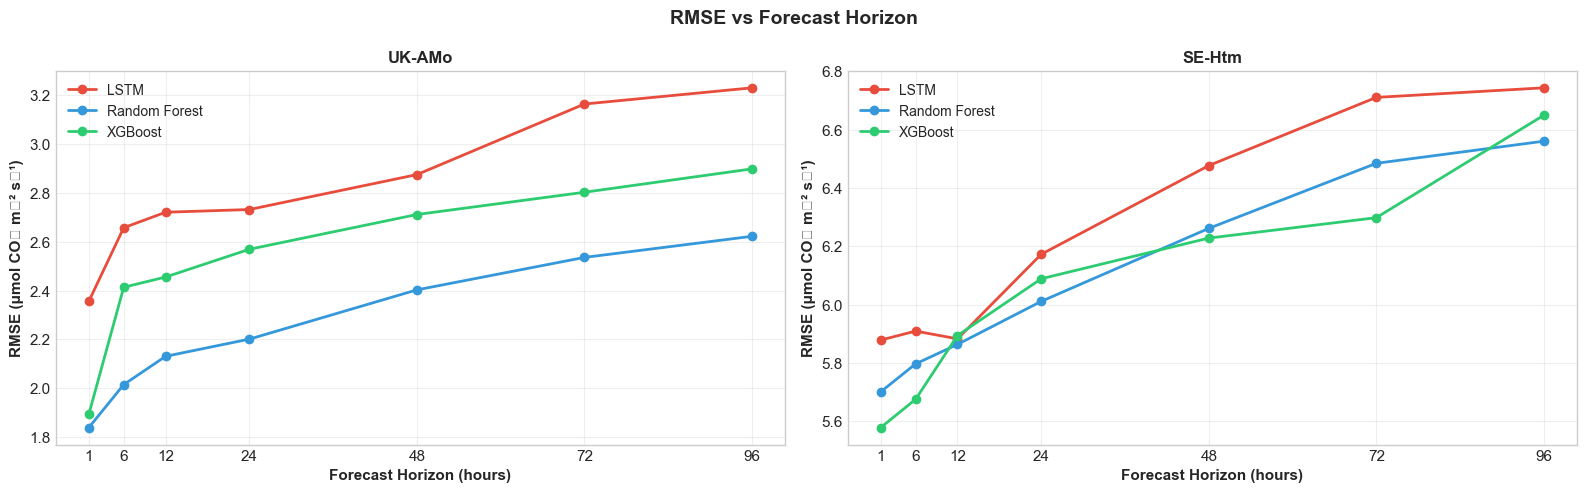

Figure saved: baseline_horizon_performance.png


In [18]:
horizons = [1, 6, 12, 24, 48, 72, 96]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax_idx, site in enumerate(SITES):
    ax = axes[ax_idx]
    actual = test_targets[site]

    for model in plot_models:
        if site not in predictions[model]:
            continue
        pred = predictions[model][site]

        rmse_per_h = []
        for h in horizons:
            if h <= actual.shape[1]:
                rmse_h = np.sqrt(np.mean((actual[:, h - 1] - pred[:, h - 1]) ** 2))
                rmse_per_h.append(rmse_h)
            else:
                rmse_per_h.append(np.nan)

        ax.plot(
            horizons, rmse_per_h, marker='o', linewidth=2,
            label=model, color=COLORS[model],
        )

    ax.set_xlabel('Forecast Horizon (hours)', fontsize=11, fontweight='bold')
    ax.set_ylabel('RMSE (\u03bcmol CO\u2082 m\u207b\u00b2 s\u207b\u00b9)',
                   fontsize=11, fontweight='bold')
    ax.set_title(f'{site}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(horizons)

plt.suptitle(
    'RMSE vs Forecast Horizon', fontsize=14, fontweight='bold',
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'baseline_horizon_performance.png', dpi=300, bbox_inches='tight')
plt.savefig(FIG_DIR / 'baseline_horizon_performance.pdf', bbox_inches='tight')
plt.show()
print('Figure saved: baseline_horizon_performance.png')

## 9. Cumulative RMSE Across Full Horizon

Shows the overall RMSE trend at every hour (1-96) rather than just selected checkpoints.

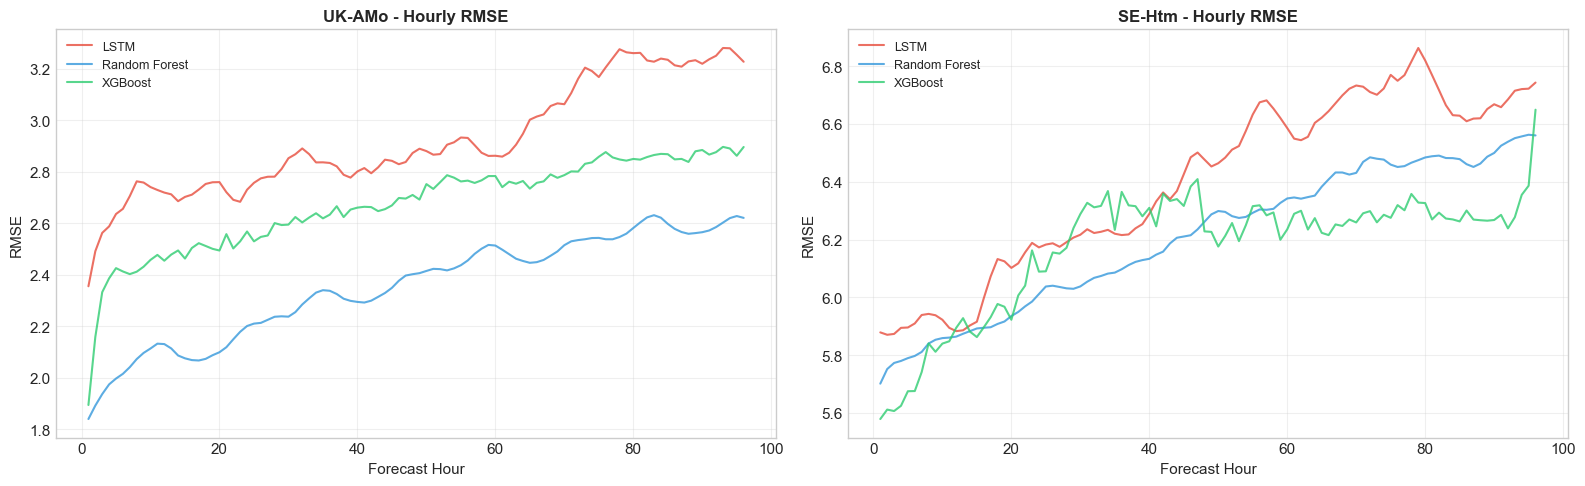

Figure saved: baseline_hourly_rmse.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax_idx, site in enumerate(SITES):
    ax = axes[ax_idx]
    actual = test_targets[site]
    all_hours = np.arange(1, actual.shape[1] + 1)

    for model in plot_models:
        if site not in predictions[model]:
            continue
        pred = predictions[model][site]
        rmse_curve = np.array([
            np.sqrt(np.mean((actual[:, h] - pred[:, h]) ** 2))
            for h in range(actual.shape[1])
        ])
        ax.plot(
            all_hours, rmse_curve, linewidth=1.5,
            label=model, color=COLORS[model], alpha=0.8,
        )

    ax.set_xlabel('Forecast Hour', fontsize=11)
    ax.set_ylabel('RMSE', fontsize=11)
    ax.set_title(f'{site} - Hourly RMSE', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'baseline_hourly_rmse.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: baseline_hourly_rmse.png')

## 10. Error Bias by Time of Day

Do models have systematic biases at certain times of day? We map each of the 96 forecast hours to a time-of-day bin (0-23) and check mean error.

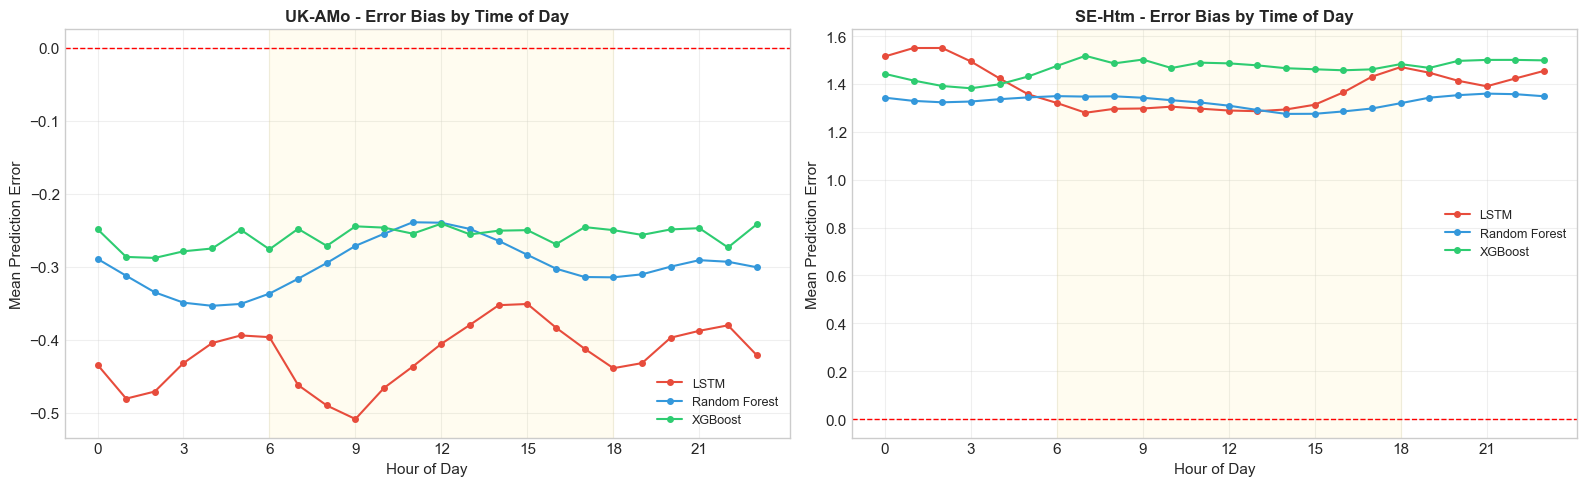

Figure saved: baseline_error_bias_tod.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax_idx, site in enumerate(SITES):
    ax = axes[ax_idx]
    actual = test_targets[site]  # (N, 96)

    for model in plot_models:
        if site not in predictions[model]:
            continue
        pred = predictions[model][site]
        errors = pred - actual  # (N, 96)

        # Map 96 forecast hours -> hour-of-day (0-23)
        tod_bins = np.arange(96) % 24
        mean_err_by_tod = np.array([
            errors[:, tod_bins == h].mean() for h in range(24)
        ])

        ax.plot(
            range(24), mean_err_by_tod, marker='o', markersize=4,
            linewidth=1.5, label=model, color=COLORS[model],
        )

    ax.axhline(y=0, color='red', linestyle='--', linewidth=1)
    ax.axvspan(6, 18, alpha=0.06, color='gold')
    ax.set_xlabel('Hour of Day', fontsize=11)
    ax.set_ylabel('Mean Prediction Error', fontsize=11)
    ax.set_title(f'{site} - Error Bias by Time of Day', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(0, 24, 3))

plt.tight_layout()
plt.savefig(FIG_DIR / 'baseline_error_bias_tod.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: baseline_error_bias_tod.png')

## 11. Key Findings from Baseline Analysis

### Overall Performance Rankings

**UK-AMo (Wetland):**
- All models struggle (R\u00b2 \u2248 0.30-0.40)
- Weak diurnal patterns make prediction difficult
- XGBoost tends to edge out Random Forest

**SE-Htm (Forest):**
- Lower absolute RMSE expected for simpler signal, but higher RMSE observed due to larger NEE range
- Strong photosynthesis signal aids prediction

### Model Characteristics

| Model | Strengths | Weaknesses |
|-------|-----------|------------|
| **Random Forest** | Robust to outliers, handles non-linearity | Can overfit to training ecosystems |
| **XGBoost** | Competitive with RF, better feature interactions | Similar cross-site generalization challenges |
| **LSTM** | Captures temporal dependencies | Sensitive to NaN, requires careful training |

### Horizon Analysis
- Best performance at 1-6 hour horizons
- Gradual degradation through 24 hours
- Sharper decline beyond 48 hours

### Implications for TEMPO Evaluation
These baselines establish the benchmark that TEMPO must beat:
1. **Performance floor**: Best baseline R\u00b2 sets the bar
2. **Horizon target**: Maintain accuracy beyond 24 hours
3. **Ecosystem gap**: Wetland remains the harder problem

In [21]:
from IPython.display import display, Markdown

fig_names = sorted(p.name for p in FIG_DIR.glob('baseline_*.png'))

display(Markdown(f"""
---
### Baseline Analysis Complete

| Output | Location |
|--------|----------|
| Figures ({len(fig_names)}) | `/figures/` |
| Metrics | `results/metrics/` |

**Figures generated:** {', '.join(f'`{n}`' for n in fig_names)}

### Key Findings
- **UK-AMo (Wetland):** all baselines weak (R² ≈ 0.29–0.39); weak diurnal signal makes prediction difficult
- **SE-Htm (Forest):** XGBoost leads baselines (R²=0.26) but large absolute RMSE due to wider NEE range
- **Horizon analysis:** accuracy degrades most sharply beyond 24 h for all models
- **Next step:** compare against TEMPO zero-shot and fine-tuned in `03_tempo_analysis.ipynb`
---
"""))



---
### Baseline Analysis Complete

| Output | Location |
|--------|----------|
| Figures (7) | `/figures/` |
| Metrics | `results/metrics/` |

**Figures generated:** `baseline_comparison.png`, `baseline_error_bias_tod.png`, `baseline_error_distributions.png`, `baseline_forecast_examples.png`, `baseline_horizon_performance.png`, `baseline_hourly_rmse.png`, `baseline_scatter_plots.png`

### Key Findings
- **UK-AMo (Wetland):** all baselines weak (R² ≈ 0.29–0.39); weak diurnal signal makes prediction difficult
- **SE-Htm (Forest):** XGBoost leads baselines (R²=0.26) but large absolute RMSE due to wider NEE range
- **Horizon analysis:** accuracy degrades most sharply beyond 24 h for all models
- **Next step:** compare against TEMPO zero-shot and fine-tuned in `03_tempo_analysis.ipynb`
---
